In [1]:
import os
import glob
from typing import Dict, List, Tuple, Optional

import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from pcmdi_enso_reader import (
    ENSODiagReader
)

In [2]:
class ENSOStaPlotter:
    """
    Plot diagnostics for ENSO diversity metrics from `data_dict`.

    Expected data_dict structure:
        data_dict[var_name] = {
            "reference": DataArray(sample, ...),
            "hist":      DataArray(sample, ...),
            "future":    DataArray(sample, ...),
        }
    """

    def __init__(
        self,
        data_dict,
        target_group="ENSO_perf",
        target_metric="enso_sst_diversity_mode2",
        fig_dir=".",
        fig_fmt="png",
    ):
        self.data_dict = data_dict
        self.target_group = target_group
        self.target_metric = target_metric
        self.fig_dir = fig_dir
        self.fig_fmt = fig_fmt

        os.makedirs(self.fig_dir, exist_ok=True)

    # -----------------------------
    # Internal helpers
    # -----------------------------
    def _get_values(self, var, group):
        """Return 1D np.ndarray of non-NaN values for a given variable & group."""
        da = self.data_dict[var][group]
        vals = da.values.ravel()
        return vals[~np.isnan(vals)]

    def compute_custom_box_stats(self, vals, label):
        """
        Custom boxplot statistics for matplotlib.bxp:
          - q1  = 5th percentile
          - med = median
          - q3  = 95th percentile
          - whislo  = min(vals)
          - whishi  = max(vals)
        """
        vals = np.asarray(vals)
        vals = vals[~np.isnan(vals)]

        if vals.size == 0:
            raise ValueError(f"No valid data for {label} (all NaN or empty).")

        stats = {
            "label": label,
            "mean": float(np.mean(vals)),
            "med": float(np.median(vals)),
            "q1": float(np.percentile(vals, 5)),
            "q3": float(np.percentile(vals, 95)),
            "whislo": float(vals.min()),
            "whishi": float(vals.max()),
            "fliers": [],
        }
        return stats
        
    @staticmethod
    def _format_lon(lon):
        """
        Format longitude in 0–360 degrees as E/W.
        """
        lon = float(lon)
        
        if np.isnan(lon):
            return ""
    
        if lon == 0 or lon == 360:
            return "0°"
            
        if lon == 180:
            return "180°"
    
        if lon < 180:
            return f"{int(lon)}°E"
        else:
            return f"{int(360 - lon)}°W"

    # -----------------------------
    # Single-panel, all variables
    # -----------------------------
    def plot_enso_lon_box(
        self,
        variables=None,
        title=None,
        xlabel="",
        ylabel="Diagnostic value",
        ylim=None,
        figsize=None,
        figgrps=None,
        figdict=None,
        format_lon=False,
        fig_dpi=150,
        fig_format='png',
        fname=None,
        var_labels=None,
        font_size=12,
        group_spacing=1.4,     # ★ NEW: spacing between groups (default > 1 for wider gaps)
    ):
        """
        Plot all variables in one panel using custom percentiles:
          - Q1 = 5th percentile
          - Q2 = median
          - Q3 = 95th percentile
          - whiskers = min, max
        """
        
        # Variables to plot
        if variables is None:
            variables = list(self.data_dict.keys())

        data_dict = self.data_dict
        ngroups = len(variables)
        width = 0.25
        
        #x0 = np.arange(ngroups)
        x0 = np.arange(ngroups) * group_spacing

        if figsize is None:
            figsize = (1.6 * ngroups + 3, 6)

        fig = plt.figure(figsize=figsize)
        # Force fixed subplot geometry (critical for combined layout)
        gs = fig.add_gridspec(
            1, 1,
            left=0.18,    # margin left
            right=0.97,   # margin right
            bottom=0.16,  # margin bottom
            top=0.90      # margin top
        )
        
        ax = fig.add_subplot(gs[0, 0])

        # --- font sizes ---
        ax.set_xlabel(xlabel, fontsize=fontz * 1.0)
        ax.set_ylabel(ylabel, fontsize=fontz * 1.0)
        ax.set_title(title,  fontsize=fontz * 1.1, loc="left")
        ax.tick_params(
            axis="both", 
            length=8,         # tick length (points)
            width=0.8,        # tick line width
            direction="out",  # or "in", "inout"
            labelsize=fontz * 0.95
        )

        # Loop through variables and groups
        legend_labels = {}
        for i, var in enumerate(variables):
            for j, group in enumerate(figgrps):

                vals = self._get_values(var, group)
                stats = self.compute_custom_box_stats(vals, label=f"{var}-{group}")

                xpos = x0[i] + (j - 1) * width  # left/center/right offset
                color = figdict[group]['color']
                alpha = figdict[group]['alpha'] 
                if group not in legend_labels:
                    legend_labels[group] = figdict[group]['label']
                    
                bp = ax.bxp(
                    [stats],
                    positions=[xpos],
                    widths=width * 0.8,
                    showmeans=True,
                    meanprops=dict(
                        marker="o",
                        markerfacecolor=color,
                        markeredgecolor=color,
                        markersize=7,
                        markeredgewidth=0
                    ),
                    medianprops=dict(
                        color=color, 
                        linewidth=2
                    ),                 
                    patch_artist=True,
                )

                for patch in bp["boxes"]:
                    patch.set_facecolor(color)
                    patch.set_alpha(alpha)

        # x-axis labels (optionally mapped through var_labels)
        xticklabels = []
        for var in variables:
            if isinstance(var_labels, dict):
                xticklabels.append(var_labels.get(var, var))
            else:
                xticklabels.append(var)

        ax.set_xticks(x0)
        ax.set_xticklabels(xticklabels, rotation=0, ha="center", fontsize=font_size)

        yticks = ax.get_yticks()
        ax.set_yticks(yticks) 

        if format_lon:
            ax.set_yticklabels([self._format_lon(t) for t in yticks], fontsize=font_size*0.95)
        else:
            ax.set_yticklabels([t for t in yticks], fontsize=font_size*0.95)

        # y-limits
        if ylim is not None:
            ax.set_ylim(*ylim)
            
        # Grid & layout
        ax.grid(True, linestyle="--", alpha=0.4)
        # Legend
        handles = [
            Patch(facecolor=figdict[g]['color'], alpha=figdict[g]['alpha'] , edgecolor="black", label=g)
            for g in figgrps
        ]
        
        handle_labels = [ legend_labels[key] for key in legend_labels.keys() ] 
        ax.legend(handles, handle_labels, loc="best", fontsize=font_size*0.9)

        fig.subplots_adjust(
            left=0.22, right=0.97, bottom=0.16, top=0.90
        )
        
        out_path = os.path.join(self.fig_dir, fname)
        fig.savefig(
            out_path, 
            dpi=fig_dpi, 
            format=fig_format, 
            bbox_inches="tight", 
            pad_inches=0.05
        )
        print("Saved figure:", out_path)
        plt.show()
        plt.close(fig)
        

Available ENSO groups: ['ENSO_perf', 'ENSO_proc', 'ENSO_tel']
Variables in ENSO_perf: ['pr_lat_rmse', 'pr_lon_rmse', 'sst_lon_rmse', 'taux_lon_rmse', 'enso_amplitude', 'enso_duration', 'enso_seasonality', 'enso_sst_diversity_mode1', 'enso_sst_diversity_mode2', 'enso_sst_lon_rmse', 'enso_sst_skewness', 'enso_sst_ts_rmse', 'seasonal_pr_lat_rmse', 'seasonal_pr_lon_rmse', 'seasonal_sst_lon_rmse', 'seasonal_taux_lon_rmse']

>>> Loading target_var = Enso_lon_pos_maxSSTA
processing period: hist
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0051/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20260213*_EnsoSstDiversity_2.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0091/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20260213*_EnsoSstDiversity_2.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0101/pcmdi_diags/model_vs_obs/

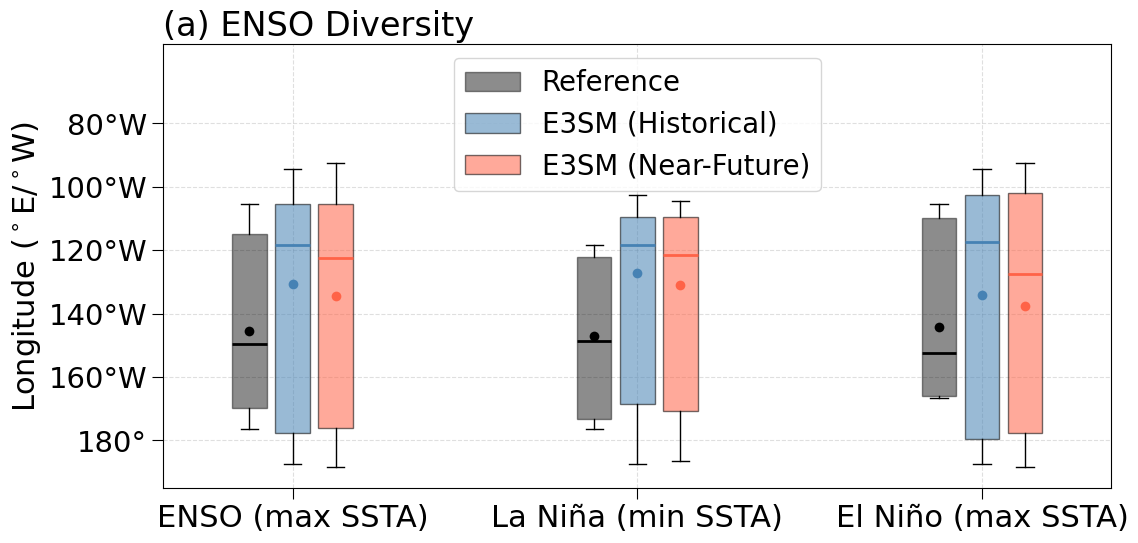

Available ENSO groups: ['ENSO_perf', 'ENSO_proc', 'ENSO_tel']
Variables in ENSO_perf: ['pr_lat_rmse', 'pr_lon_rmse', 'sst_lon_rmse', 'taux_lon_rmse', 'enso_amplitude', 'enso_duration', 'enso_seasonality', 'enso_sst_diversity_mode1', 'enso_sst_diversity_mode2', 'enso_sst_lon_rmse', 'enso_sst_skewness', 'enso_sst_ts_rmse', 'seasonal_pr_lat_rmse', 'seasonal_pr_lon_rmse', 'seasonal_sst_lon_rmse', 'seasonal_taux_lon_rmse']

>>> Loading target_var = Nina_duration
processing period: hist
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0051/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20260213*_EnsoDuration.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0091/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20260213*_EnsoDuration.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0101/pcmdi_diags/model_vs_obs/metrics_data/enso_m

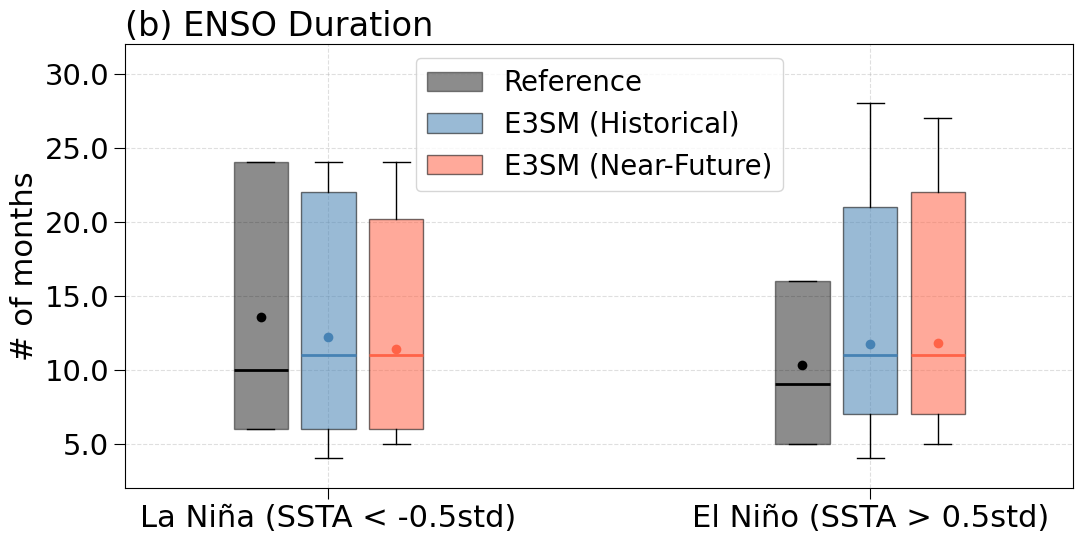

In [6]:
if __name__ == "__main__":
    TOP_DIR   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper"
    DATA_DIR  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le"
    OUT_DIR   = f"{TOP_DIR}/figure_data"
    FIG_DIR   = "./"
    os.makedirs(OUT_DIR, exist_ok=True)
    os.makedirs(FIG_DIR, exist_ok=True)

    # ---- Pair experiments consistently (order matters) ----
    MODEL   = "v3.LR.historical"
    GROUP   = ["hist", "future"]
    PERIOD  = [(1985, 2014), (2015, 2049)]
    NENS    = [25, 25]
    case_id = "v20260213"

    members = None
    verbose = False
    diag_print = True 
    fig_idx_start = 0 
    
    reader = ENSODiagReader(
        data_dir=DATA_DIR,
        model=MODEL,
        groups=GROUP,
        period_list=PERIOD,
        nens=NENS,
        members=members,
        verbose=verbose,
    )

    target_metric_dict = {
        "enso_sst_diversity_mode2" : {
            "vars": ["Enso_lon_pos_maxSSTA","Nina_lon_pos_minSSTA","Nino_lon_pos_maxSSTA"],
            "vmap": {
                "Enso_lon_pos_maxSSTA": "ENSO (max SSTA)",
                "Nina_lon_pos_minSSTA": "La Niña (min SSTA)",
                "Nino_lon_pos_maxSSTA": "El Niño (max SSTA)",
            },
            "obs" : {"hist": "TropFlux","future": "FAKE-FUTURE2"},
            "group" : "ENSO_perf",
            "label" : "ENSO Diversity",
            "unit" : r"Longitude ($^\circ$E/$^\circ$W)",
            "ymin" : 165,
            "ymax" : 305,
            "rtol" : 1e-2,
            "format_lon": True,
        },
        "enso_duration" : {
            "vars": ["Nina_duration","Nino_duration"],
            "vmap": {
                "Nina_duration": "La Niña (SSTA < -0.5std)",
                "Nino_duration": "El Niño (SSTA > 0.5std)",
            },
            "obs" : {"hist": "TropFlux","future": "FAKE-FUTURE2"},
            "group": "ENSO_perf",
            "label": "ENSO Duration",
            "unit" : r"# of months",
            "ymin" : 2,
            "ymax" : 32,
            "rtol" : 1e-2,
            "format_lon": False,
        },
    }
    
    pool_members_to_samples = True

    for i,target_metric in enumerate(target_metric_dict.keys()):
        target_var_list = target_metric_dict[target_metric]['vars']
        target_obs_dict = target_metric_dict[target_metric]['obs'] 
        target_group = target_metric_dict[target_metric]['group']  
        target_rtol = target_metric_dict[target_metric]['rtol']
        target_ymin = target_metric_dict[target_metric]['ymin']
        target_ymax = target_metric_dict[target_metric]['ymax']
        target_label = target_metric_dict[target_metric]['label']
        target_unit = target_metric_dict[target_metric]['unit']
        var_label_map = target_metric_dict[target_metric]['vmap']
        format_lon = target_metric_dict[target_metric]['format_lon']
        
        # ---- Sanity checks ----
        print("Available ENSO groups:", reader.available_groups())
        print(f"Variables in {target_group}:", reader.available_vars(target_group))
    
        if target_group not in reader.available_groups():
            raise ValueError(f"Unknown target_group: {target_group}")
    
        if target_metric not in reader.available_vars(target_group):
            raise ValueError(f"Unknown target_metric '{target_metric}' for '{target_group}'")
    
        # ----------------------------------------------------
        # Loop through target variable list
        # ----------------------------------------------------
        data_dict = {}   # model hist+ model future + obs 
        for j,target_var in enumerate(target_var_list):
            print(f"\n>>> Loading target_var = {target_var}")
            data_dict[target_var] = {} 
            
            # Load model + obs using your working function
            dm, do = reader.load_metric_data(
                enso_group=target_group,
                var_name=target_metric,
                nc_var=target_var,
                ref_dict=target_obs_dict,
                case_id=case_id,
            )
    
            # observation only has one member and is identical for historical and near-future
            #print(do["hist"]["00"].values)
            #print(do["future"]["00"].values)
        
            ref = reader.validate_constant_observation(
                do, ref_group="hist", ref_member="00", sample_dim=None,
                use_allclose=True,rtol=target_rtol, atol=0.0,
                pool_ensemble = pool_members_to_samples, 
            )
            
            # If we get here, all obs are identical
            # ref is the DataArray you want to keep
            data_dict[target_var]['reference'] = ref
            for group, member_dict in dm.items():
                print(f"  Group: {group}")
                pooled = reader.pool_members_to_samples(member_dict, sample_dim=None)  
                data_dict[target_var][group] = pooled
                
            print("\n✓ All target_var successfully read.")
        
            if diag_print: 
                print(f"\nVariable: {target_var}")
                for group, da in data_dict.items():
                    print(f"  Group: {group}")
                    # da is an xarray DataArray or Dataset
                    shape = getattr(da, "shape", None)
                    dims  = getattr(da, "dims", None)
                    print(f"type={type(da).__name__} | shape={shape} | dims={dims}")
                    
        plot_groups = ['reference'] + GROUP
        plot_dict = {        
            "reference": {
                "label": "Reference", 
                "color": "black",
                "alpha": 0.45,
            },
            "hist": {
                "label": "E3SM (Historical)",
                "color": "steelblue",
                "alpha": 0.55,
            },
            "future": {
                "label": "E3SM (Near-Future)",
                "color": "tomato",
                "alpha": 0.55,
            },
        }
        
        figure_name = f"enso_{target_metric}_hist_future_ens.pdf"
        title       =  f"({chr(i + fig_idx_start  + 97)}) {target_label}"  
        xlabel      = ""
        ylabel      = rf"{target_unit}"
        fontz       = 22
        figure_size = (12, 6)
        fig_format  = "pdf"
        fig_dpi     = 300 
        group_spacing = 2.0     # ★ NEW: spacing between groups (default > 1 for wider gaps)

        plotter = ENSOStaPlotter(
            data_dict=data_dict,
            target_group=target_group,
            target_metric=target_metric,
            fig_dir=FIG_DIR,
            fig_fmt=fig_format, 
        )

        plotter.plot_enso_lon_box(
            variables=target_var_list,
            title=title,
            xlabel=xlabel,
            ylabel=ylabel,
            ylim=(target_ymin, target_ymax),
            figsize=figure_size,
            figdict=plot_dict,
            figgrps=plot_groups,
            fname=figure_name, 
            var_labels=var_label_map,
            font_size=fontz,
            format_lon=format_lon,
            group_spacing=group_spacing,
            fig_dpi=fig_dpi,
            fig_format=fig_format,
        )    

In [4]:
if __name__ == "__main__":
    TOP_DIR   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper"
    DATA_DIR  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le"
    OUT_DIR   = f"{TOP_DIR}/figure_data"
    FIG_DIR   = "./"
    os.makedirs(OUT_DIR, exist_ok=True)
    os.makedirs(FIG_DIR, exist_ok=True)

    # ---- Pair experiments consistently (order matters) ----
    MODEL   = "v3.LR.historical"
    GROUP   = ["hist", "future"]
    PERIOD  = [(1985, 2014), (2015, 2049)]
    NENS    = [25, 25]
    case_id = "v20251015"

    members = None
    verbose = False
    diag_print = True 
    fig_idx_start = 0 
    
    reader = ENSODiagReader(
        data_dir=DATA_DIR,
        model=MODEL,
        groups=GROUP,
        period_list=PERIOD,
        nens=NENS,
        members=members,
        verbose=verbose,
    )

    target_metric_dict = {
        "enso_sst_diversity_mode2" : {
            "vars": ["Enso_lon_pos_maxSSTA","Nina_lon_pos_minSSTA","Nino_lon_pos_maxSSTA"],
            "vmap": {
                "Enso_lon_pos_maxSSTA": "ENSO (max SSTA)",
                "Nina_lon_pos_minSSTA": "La Niña (min SSTA)",
                "Nino_lon_pos_maxSSTA": "El Niño (max SSTA)",
            },
            "obs" : {"hist": "ERA-Interim","future": "ERA-Interim2"},
            "group" : "ENSO_perf",
            "label" : "ENSO Diversity",
            "unit" : r"Longitude ($^\circ$E/$^\circ$W)",
            "ymin" : 165,
            "ymax" : 305,
            "rtol" : 1e-2,
            "format_lon": True,
        },
        "enso_duration" : {
            "vars": ["Nina_duration","Nino_duration"],
            "vmap": {
                "Nina_duration": "La Niña (SSTA < -0.5std)",
                "Nino_duration": "El Niño (SSTA > 0.5std)",
            },
            "obs" : {"hist": "ERA-Interim","future": "ERA-Interim2"},
            "group": "ENSO_perf",
            "label": "ENSO Duration",
            "unit" : r"# of months",
            "ymin" : 2,
            "ymax" : 32,
            "rtol" : 1e-2,
            "format_lon": False,
        },
    }
    
    pool_members_to_samples = True

    for i,target_metric in enumerate(target_metric_dict.keys()):
        target_var_list = target_metric_dict[target_metric]['vars']
        target_obs_dict = target_metric_dict[target_metric]['obs'] 
        target_group = target_metric_dict[target_metric]['group']  
        target_rtol = target_metric_dict[target_metric]['rtol']
        target_ymin = target_metric_dict[target_metric]['ymin']
        target_ymax = target_metric_dict[target_metric]['ymax']
        target_label = target_metric_dict[target_metric]['label']
        target_unit = target_metric_dict[target_metric]['unit']
        var_label_map = target_metric_dict[target_metric]['vmap']
        format_lon = target_metric_dict[target_metric]['format_lon']
        
        # ---- Sanity checks ----
        print("Available ENSO groups:", reader.available_groups())
        print(f"Variables in {target_group}:", reader.available_vars(target_group))
    
        if target_group not in reader.available_groups():
            raise ValueError(f"Unknown target_group: {target_group}")
    
        if target_metric not in reader.available_vars(target_group):
            raise ValueError(f"Unknown target_metric '{target_metric}' for '{target_group}'")
    
        # ----------------------------------------------------
        # Loop through target variable list
        # ----------------------------------------------------
        data_dict = {}   # model hist+ model future + obs 
        for j,target_var in enumerate(target_var_list):
            print(f"\n>>> Loading target_var = {target_var}")
            data_dict[target_var] = {} 
            
            # Load model + obs using your working function
            dm, do = reader.load_metric_data(
                enso_group=target_group,
                var_name=target_metric,
                nc_var=target_var,
                ref_dict=target_obs_dict,
            )
    
            # observation only has one member and is identical for historical and near-future
            #print(do["hist"]["00"].values)
            #print(do["future"]["00"].values)
        
            ref = reader.validate_constant_observation(
                do, ref_group="hist", ref_member="00", sample_dim=None,
                use_allclose=True,rtol=target_rtol, atol=0.0,
                pool_ensemble = pool_members_to_samples, 
            )
            
            # If we get here, all obs are identical
            # ref is the DataArray you want to keep
            data_dict[target_var]['reference'] = ref
            for group, member_dict in dm.items():
                print(f"  Group: {group}")
                pooled = reader.pool_members_to_samples(member_dict, sample_dim=None)  
                data_dict[target_var][group] = pooled
                
            print("\n✓ All target_var successfully read.")
        
            if diag_print: 
                print(f"\nVariable: {target_var}")
                for group, da in data_dict.items():
                    print(f"  Group: {group}")
                    # da is an xarray DataArray or Dataset
                    shape = getattr(da, "shape", None)
                    dims  = getattr(da, "dims", None)
                    print(f"type={type(da).__name__} | shape={shape} | dims={dims}")
                    
        plot_groups = ['reference'] + GROUP
        plot_dict = {        
            "reference": {
                "label": "Reference", 
                "color": "black",
                "alpha": 0.45,
            },
            "hist": {
                "label": "E3SM (Historical)",
                "color": "steelblue",
                "alpha": 0.55,
            },
            "future": {
                "label": "E3SM (Near-Future)",
                "color": "tomato",
                "alpha": 0.55,
            },
        }
        
        figure_name = f"enso_{target_metric}_hist_future_ens.pdf"
        title       =  f"({chr(i + fig_idx_start  + 97)}) {target_label}"  
        xlabel      = ""
        ylabel      = rf"{target_unit}"
        fontz       = 22
        figure_size = (12, 6)
        fig_format  = "pdf"
        fig_dpi     = 300 
        group_spacing = 2.0     # ★ NEW: spacing between groups (default > 1 for wider gaps)

        plotter = ENSOStaPlotter(
            data_dict=data_dict,
            target_group=target_group,
            target_metric=target_metric,
            fig_dir=FIG_DIR,
            fig_fmt=fig_fmt, 
        )

        plotter.plot_enso_lon_box(
            variables=target_var_list,
            title=title,
            xlabel=xlabel,
            ylabel=ylabel,
            ylim=(target_ymin, target_ymax),
            figsize=figure_size,
            figdict=plot_dict,
            figgrps=plot_groups,
            fname=figure_name, 
            var_labels=var_label_map,
            font_size=fontz,
            format_lon=format_lon,
            group_spacing=group_spacing,
            fig_dpi=fig_dpi,
            fig_format=fig_format,
        )    

Available ENSO groups: ['ENSO_perf', 'ENSO_proc', 'ENSO_tel']
Variables in ENSO_perf: ['pr_lat_rmse', 'pr_lon_rmse', 'sst_lon_rmse', 'taux_lon_rmse', 'enso_amplitude', 'enso_duration', 'enso_seasonality', 'enso_sst_diversity_mode1', 'enso_sst_diversity_mode2', 'enso_sst_lon_rmse', 'enso_sst_skewness', 'enso_sst_ts_rmse', 'seasonal_pr_lat_rmse', 'seasonal_pr_lon_rmse', 'seasonal_sst_lon_rmse', 'seasonal_taux_lon_rmse']

>>> Loading target_var = Enso_lon_pos_maxSSTA
processing period: hist
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0051/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*None*_EnsoSstDiversity_2.nc


FileNotFoundError: No file matching *_EnsoSstDiversity_2.nc in /lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0051/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf